<a href="https://colab.research.google.com/github/UttamPachauri/Research-Paper-Intelligence-System-using-Agentic-AI/blob/main/Research_Paper_Intelligence_System_AgenticAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Research Paper Intelligence System using Agentic AI

## Project Overview

This project is an Agentic AI-based Research Paper Intelligence System.

Features:
- Semantic Search using FAISS
- Research Paper Summarization
- Keyword Extraction
- Named Entity Recognition (NER)
- Paper Comparison
- Conversational Memory
- LangChain Agent
- Groq LLM Integration

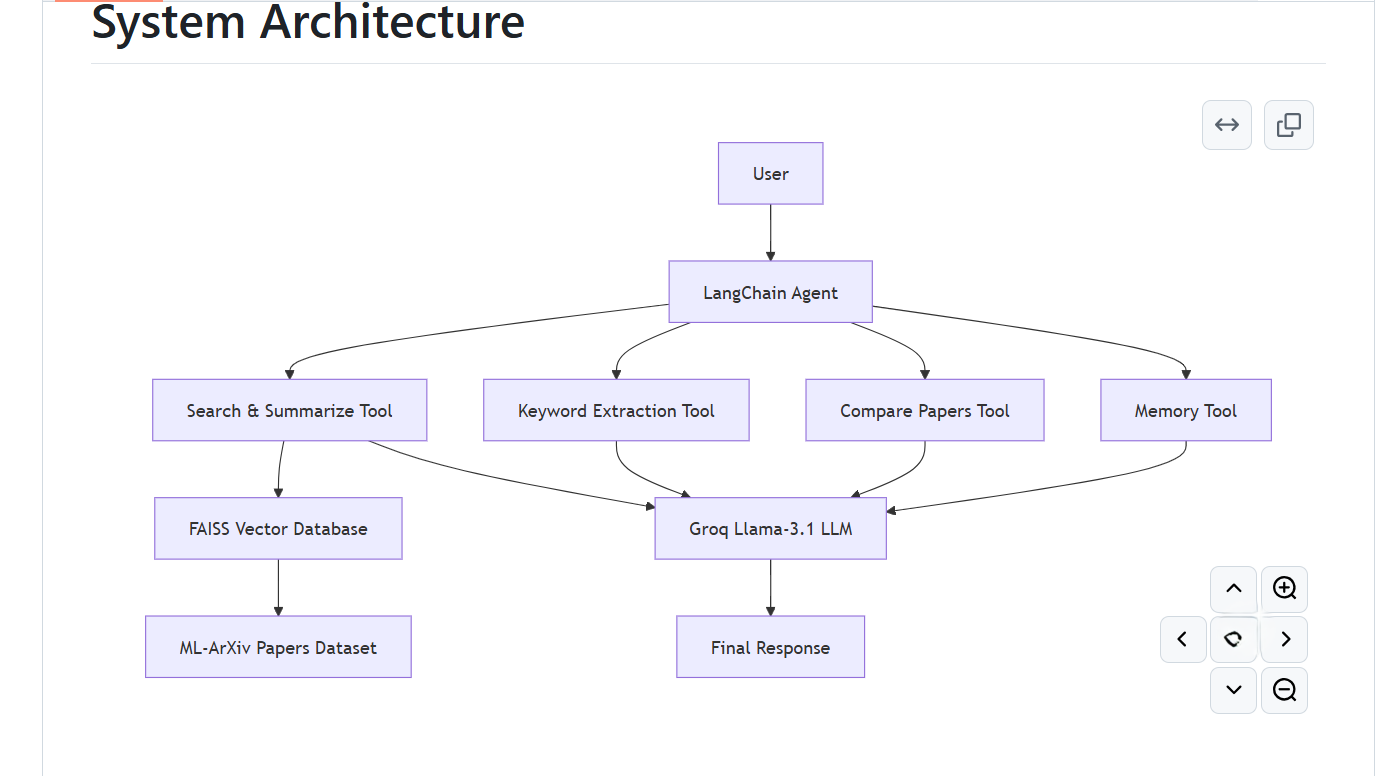

## Step 1 : Install Libraries

In [ ]:
!pip install -q transformers==4.53.3
!pip install -q sentence-transformers==5.0.0
!pip install -q faiss-cpu==1.12.0
!pip install -q keybert==0.9.0
!pip install -q datasets
!pip install -q langchain==1.3.11
!pip install -q langgraph==1.2.9
!pip install -q langchain-groq
!pip install -q langchain-community
!pip install -q langchain-huggingface

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 58.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.19.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 470.2/470.2 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.5/247.5 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 8.3 MB/s eta 0:00:0

## Step 2 : Import Libraries

In [ ]:
import pandas as pd
import numpy as np

import faiss

from sentence_transformers import SentenceTransformer

from transformers import pipeline

from keybert import KeyBERT

from langchain_core.tools import tool

from langchain.agents import create_agent

from langgraph.checkpoint.memory import MemorySaver

from langchain_groq import ChatGroq

from langchain_huggingface import HuggingFacePipeline

## Step 3 : Load Dataset

In [ ]:
from datasets import load_dataset

dataset = load_dataset(
    "CShorten/ML-ArXiv-Papers",
    split="train"
)

print(dataset)

README.md:   0%|          | 0.00/986 [00:00<?, ?B/s]

ML-Arxiv-Papers.csv:   0%|          | 0.00/147M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['Unnamed: 0.1', 'Unnamed: 0', 'title', 'abstract'],
    num_rows: 117592
})


In [ ]:
dataset[0]

{'Unnamed: 0.1': 0,
 'Unnamed: 0': 0.0,
 'title': 'Learning from compressed observations',
 'abstract': '  The problem of statistical learning is to construct a predictor of a random\nvariable $Y$ as a function of a related random variable $X$ on the basis of an\ni.i.d. training sample from the joint distribution of $(X,Y)$. Allowable\npredictors are drawn from some specified class, and the goal is to approach\nasymptotically the performance (expected loss) of the best predictor in the\nclass. We consider the setting in which one has perfect observation of the\n$X$-part of the sample, while the $Y$-part has to be communicated at some\nfinite bit rate. The encoding of the $Y$-values is allowed to depend on the\n$X$-values. Under suitable regularity conditions on the admissible predictors,\nthe underlying family of probability distributions and the loss function, we\ngive an information-theoretic characterization of achievable predictor\nperformance in terms of conditional distortion-rat

In [ ]:
import pandas as pd

df = pd.DataFrame(dataset)

df.head()

,Unnamed: 0.1,Unnamed: 0,title,abstract
0,0,0.0,Learning from compressed observations,The problem of statistical learning is to co...
1,1,1.0,Sensor Networks with Random Links: Topology De...,"In a sensor network, in practice, the commun..."
2,2,2.0,The on-line shortest path problem under partia...,The on-line shortest path problem is conside...
3,3,3.0,A neural network approach to ordinal regression,Ordinal regression is an important type of l...
4,4,4.0,Parametric Learning and Monte Carlo Optimization,This paper uncovers and explores the close r...


In [ ]:
df.shape

(117592, 4)

In [ ]:
df.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'title', 'abstract'], dtype='object')

In [ ]:
df = df[['title', 'abstract']]

In [ ]:
df.head()

,title,abstract
0,Learning from compressed observations,The problem of statistical learning is to co...
1,Sensor Networks with Random Links: Topology De...,"In a sensor network, in practice, the commun..."
2,The on-line shortest path problem under partia...,The on-line shortest path problem is conside...
3,A neural network approach to ordinal regression,Ordinal regression is an important type of l...
4,Parametric Learning and Monte Carlo Optimization,This paper uncovers and explores the close r...


In [ ]:
df = df.head(15000)

In [ ]:
df.shape

(15000, 2)

In [ ]:
df.isnull().sum()

,0
title,0
abstract,0


In [ ]:
df["paper_text"] = df["title"] + " " + df["abstract"]

In [ ]:
df[["paper_text"]].head()

,paper_text
0,Learning from compressed observations The pr...
1,Sensor Networks with Random Links: Topology De...
2,The on-line shortest path problem under partia...
3,A neural network approach to ordinal regressio...
4,Parametric Learning and Monte Carlo Optimizati...


In [ ]:
type(df[["paper_text"]])

pandas.core.frame.DataFrame

In [ ]:
print(df["paper_text"].iloc[0])

Learning from compressed observations   The problem of statistical learning is to construct a predictor of a random
variable $Y$ as a function of a related random variable $X$ on the basis of an
i.i.d. training sample from the joint distribution of $(X,Y)$. Allowable
predictors are drawn from some specified class, and the goal is to approach
asymptotically the performance (expected loss) of the best predictor in the
class. We consider the setting in which one has perfect observation of the
$X$-part of the sample, while the $Y$-part has to be communicated at some
finite bit rate. The encoding of the $Y$-values is allowed to depend on the
$X$-values. Under suitable regularity conditions on the admissible predictors,
the underlying family of probability distributions and the loss function, we
give an information-theoretic characterization of achievable predictor
performance in terms of conditional distortion-rate functions. The ideas are
illustrated on the example of nonparametric regress

In [ ]:
df["paper_text"] = df["paper_text"].str.replace("\n", " ", regex=False)
df["paper_text"] = df["paper_text"].str.strip()

In [ ]:
print(df["paper_text"].iloc[0])

Learning from compressed observations   The problem of statistical learning is to construct a predictor of a random variable $Y$ as a function of a related random variable $X$ on the basis of an i.i.d. training sample from the joint distribution of $(X,Y)$. Allowable predictors are drawn from some specified class, and the goal is to approach asymptotically the performance (expected loss) of the best predictor in the class. We consider the setting in which one has perfect observation of the $X$-part of the sample, while the $Y$-part has to be communicated at some finite bit rate. The encoding of the $Y$-values is allowed to depend on the $X$-values. Under suitable regularity conditions on the admissible predictors, the underlying family of probability distributions and the loss function, we give an information-theoretic characterization of achievable predictor performance in terms of conditional distortion-rate functions. The ideas are illustrated on the example of nonparametric regress

## Step 4 : Generate Embeddings

In [ ]:
from sentence_transformers import SentenceTransformer

In [ ]:
model = SentenceTransformer('all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
print(type(model))

<class 'sentence_transformers.SentenceTransformer.SentenceTransformer'>


In [ ]:
sample_text = df["paper_text"].iloc[0]

embedding = model.encode(sample_text)

print(type(embedding))
print(embedding.shape)

<class 'numpy.ndarray'>
(384,)


In [ ]:
embedding[:10]

array([-0.1315641 , -0.00678266, -0.00367612,  0.03265158,  0.11219642,
        0.01227267,  0.09816719, -0.0900523 ,  0.04231161, -0.01977348],
      dtype=float32)

In [ ]:
sample_embeddings = model.encode(
    df["paper_text"].head(5).tolist()
)

print(type(sample_embeddings))
print(sample_embeddings.shape)

<class 'numpy.ndarray'>
(5, 384)


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
similarity = cosine_similarity(
    sample_embeddings[0].reshape(1, -1),
    sample_embeddings[1].reshape(1, -1)
)

print(similarity)

[[0.36625272]]


In [ ]:
similarity = cosine_similarity(
    sample_embeddings[0].reshape(1,-1),
    sample_embeddings[0].reshape(1,-1)
)

print(similarity)

[[1.0000001]]


In [ ]:
for i in range(1,5):

    sim = cosine_similarity(
        sample_embeddings[0].reshape(1,-1),
        sample_embeddings[i].reshape(1,-1)
    )

    print(f"Paper 1 vs Paper {i+1}: {sim[0][0]:.4f}")

Paper 1 vs Paper 2: 0.3663
Paper 1 vs Paper 3: 0.3352
Paper 1 vs Paper 4: 0.1551
Paper 1 vs Paper 5: 0.3742


Generate Full Embeddings

In [ ]:
import os
import numpy as np

if os.path.exists("paper_embeddings.npy"):

    print("Loading saved embeddings...")

    embeddings = np.load("paper_embeddings.npy")

else:

    print("Generating embeddings...")

    embeddings = model.encode(
        df["paper_text"].tolist(),
        batch_size=32,
        show_progress_bar=True
    )

    np.save("paper_embeddings.npy", embeddings)

    print("Embeddings saved successfully!")

Generating embeddings...


Batches:   0%|          | 0/469 [00:00<?, ?it/s]

Embeddings saved successfully!


In [ ]:
print(type(embeddings))
print(embeddings.shape)

<class 'numpy.ndarray'>
(15000, 384)


In [ ]:
embeddings.nbytes / (1024*1024)

21.97265625

In [ ]:
embeddings.dtype

dtype('float32')

## Step 5 : Build Vector Database

In [ ]:
!pip install faiss-cpu

In [ ]:
import os
import faiss

if os.path.exists("paper_faiss.index"):

    print("Loading existing FAISS index...")

    index = faiss.read_index("paper_faiss.index")

else:

    print("Creating new FAISS index...")

    faiss.normalize_L2(embeddings)

    index = faiss.IndexFlatIP(384)

    index.add(embeddings)

    faiss.write_index(index, "paper_faiss.index")

    print("FAISS index saved successfully!")

Loading existing FAISS index...


In [ ]:
import numpy as np

np.linalg.norm(embeddings[0])

np.float32(1.0)

In [ ]:
print(index.ntotal)

15000


In [ ]:
query = "deep learning for medical image analysis"
query_embedding = model.encode([query])
query_embedding.shape

(1, 384)

In [ ]:
faiss.normalize_L2(query_embedding)

np.linalg.norm(query_embedding[0])

np.float32(1.0)

In [ ]:
D, I = index.search(query_embedding, 5)

print(D)
print(I)

[[0.6807244  0.67092204 0.65219975 0.62811744 0.61311525]]
[[10466 13730 11873 12691 11282]]


In [ ]:
print(df.iloc[10466]["title"])

A Perspective on Deep Imaging


In [ ]:
print(df.iloc[10466]["abstract"])

  The combination of tomographic imaging and deep learning, or machine learning
in general, promises to empower not only image analysis but also image
reconstruction. The latter aspect is considered in this perspective article
with an emphasis on medical imaging to develop a new generation of image
reconstruction theories and techniques. This direction might lead to
intelligent utilization of domain knowledge from big data, innovative
approaches for image reconstruction, and superior performance in clinical and
preclinical applications. To realize the full impact of machine learning on
medical imaging, major challenges must be addressed.



In [ ]:
def search_papers(query, k=5):

    query_embedding = model.encode([query])

    faiss.normalize_L2(query_embedding)

    D, I = index.search(query_embedding, k)

    return D, I

In [ ]:
D, I = search_papers(
    "deep learning for medical image analysis"
)

print(D)
print(I)

[[0.6807244  0.67092204 0.65219975 0.62811744 0.61311525]]
[[10466 13730 11873 12691 11282]]


In [ ]:
def search_papers(query, k=5):

    query_embedding = model.encode([query])

    faiss.normalize_L2(query_embedding)

    D, I = index.search(query_embedding, k)

    for score, idx in zip(D[0], I[0]):

        print("=" * 100)

        print("Similarity:", round(float(score), 4))

        print("Title:", df.iloc[idx]["title"])

        print()

        print("Abstract:")

        print(df.iloc[idx]["abstract"][:500])

        print()

In [ ]:
search_papers(
    "deep learning for medical image analysis"
)

Similarity: 0.6807
Title: A Perspective on Deep Imaging

Abstract:
  The combination of tomographic imaging and deep learning, or machine learning
in general, promises to empower not only image analysis but also image
reconstruction. The latter aspect is considered in this perspective article
with an emphasis on medical imaging to develop a new generation of image
reconstruction theories and techniques. This direction might lead to
intelligent utilization of domain knowledge from big data, innovative
approaches for image reconstruction, and superior performance

Similarity: 0.6709
Title: Convolutional Neural Networks for Medical Image Analysis: Full Training
  or Fine Tuning?

Abstract:
  Training a deep convolutional neural network (CNN) from scratch is difficult
because it requires a large amount of labeled training data and a great deal of
expertise to ensure proper convergence. A promising alternative is to fine-tune
a CNN that has been pre-trained using, for instance, a large set 

## Step 6 : Research Paper Summarization using BART

In [ ]:
import transformers
print(transformers.__version__)

4.53.3


In [ ]:
from transformers import pipeline

summarizer = pipeline(
    "summarization",
    model="facebook/bart-large-cnn"
)

Device set to use cpu


In [ ]:
text = df.iloc[0]["abstract"]

summary = summarizer(
    text,
    max_length=120,
    min_length=40,
    do_sample=False
)

print(summary[0]["summary_text"])

Predictors are drawn from some specified class, and the goal is to approach the performance (expected loss) of the best predictor in the class. The ideas areillustrated on the example of nonparametric regression in Gaussian noise. Under suitable regularity conditions on the admissible predictors, we give an information-theoretic characterization of achievable predictorperformance.


In [ ]:
def summarize_text(text):

    summary = summarizer(
        text,
        max_length=120,
        min_length=40,
        do_sample=False
    )

    return summary[0]["summary_text"]

In [ ]:
summarize_text(df.iloc[5]["abstract"])

Your max_length is set to 120, but your input_length is only 69. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=34)


'This paper has been withdrawn by the author. This draft is withdrawn for its poor quality in english. Look at the ICML version instead:http://icml2008.cs.helsinki.fi/papers/111.pdf'

## Step 7 : Keyword Extraction using KeyBERT

In [ ]:
from keybert import KeyBERT

kw_model = KeyBERT()

In [ ]:
keywords = kw_model.extract_keywords(
    df.iloc[0]["abstract"],
    keyphrase_ngram_range=(1,2),
    stop_words="english",
    top_n=5
)

keywords

[('information theoretic', 0.4972),
 ('admissible predictors', 0.4638),
 ('achievable predictor', 0.4379),
 ('allowable predictors', 0.4247),
 ('statistical learning', 0.4086)]

In [ ]:
def get_keywords(text, top_n=5):

    return kw_model.extract_keywords(
        text,
        keyphrase_ngram_range=(1,2),
        stop_words="english",
        top_n=top_n
    )

In [ ]:
get_keywords(df.iloc[2]["abstract"])

[('bandit problem', 0.5839),
 ('bandit', 0.4952),
 ('bandit setting', 0.4818),
 ('path weights', 0.4629),
 ('weighted directed', 0.4423)]

## Step 8 : Named Entity Recognition (NER)

In [ ]:
from transformers import pipeline

ner = pipeline(
    "ner",
    aggregation_strategy="simple"
)

No model was supplied, defaulted to dbmdz/bert-large-cased-finetuned-conll03-english and revision 4c53496 (https://huggingface.co/dbmdz/bert-large-cased-finetuned-conll03-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/998 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Some weights of the model checkpoint at dbmdz/bert-large-cased-finetuned-conll03-english were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/60.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Device set to use cpu


In [ ]:
text = """
ResNet50 was trained on ImageNet using PyTorch
at Stanford University.
"""

entities = ner(text)

entities

[{'entity_group': 'ORG',
  'score': np.float32(0.89313775),
  'word': 'ResNet50',
  'start': 1,
  'end': 9},
 {'entity_group': 'ORG',
  'score': np.float32(0.82662463),
  'word': 'ImageNet',
  'start': 25,
  'end': 33},
 {'entity_group': 'ORG',
  'score': np.float32(0.94511735),
  'word': 'PyTorch',
  'start': 40,
  'end': 47},
 {'entity_group': 'ORG',
  'score': np.float32(0.93374425),
  'word': 'Stanford University',
  'start': 51,
  'end': 70}]

In [ ]:
for entity in entities:
    print(entity)

{'entity_group': 'ORG', 'score': np.float32(0.89313775), 'word': 'ResNet50', 'start': 1, 'end': 9}
{'entity_group': 'ORG', 'score': np.float32(0.82662463), 'word': 'ImageNet', 'start': 25, 'end': 33}
{'entity_group': 'ORG', 'score': np.float32(0.94511735), 'word': 'PyTorch', 'start': 40, 'end': 47}
{'entity_group': 'ORG', 'score': np.float32(0.93374425), 'word': 'Stanford University', 'start': 51, 'end': 70}


## Step 9 : Large Language Model (LLM) Setup

In [ ]:
from google.colab import userdata

In [ ]:
api_key = userdata.get("GROQ_API_KEY")

In [ ]:
llm = ChatGroq(
    model="llama-3.1-8b-instant",
    api_key=api_key,
    temperature=0
)

In [ ]:
response = llm.invoke("Hello, who are you?")

print(response.content)

I'm an artificial intelligence model known as a large language model (LLM) or conversational AI. I'm a computer program designed to understand and respond to human language in a way that's natural and helpful.

I don't have a personal identity or emotions like humans do, but I'm here to assist you with any questions, topics, or tasks you'd like to discuss. I can provide information, answer questions, generate text, and even engage in conversation.

I'm constantly learning and improving my responses based on the data and interactions I receive, so feel free to ask me anything and see how I can help!


## Step 10 : Add Conversation Memory

In [ ]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

In [ ]:
paper_memory = {
    "last_results": []
}

## Step 11 : Agent Tools

In [ ]:
from langchain_core.tools import tool

@tool
def search_and_summarize(query: str, k: int = 2):
    """
    Search research papers from the FAISS database,
    retrieve the top-k most similar papers,
    summarize each paper using BART,
    and return the results as structured data.
    """

    query_embedding = model.encode([query])
    faiss.normalize_L2(query_embedding)

    D, I = index.search(query_embedding, k)

    papers = []

    for rank, (score, idx) in enumerate(zip(D[0], I[0]), start=1):

        paper = df.iloc[idx]

        summary = summarizer(
            paper["abstract"],
            max_length=60,
            min_length=20,
            do_sample=False
        )[0]["summary_text"]

        paper_data = {
            "rank": rank,
            "similarity": round(float(score), 4),
            "title": paper["title"],
            "summary": summary
        }

        papers.append(paper_data)

    # Save retrieved papers into memory
    paper_memory["last_results"] = papers

    return papers

In [ ]:


@tool
def extract_keywords(text: str, top_n: int = 3) -> str:
    """
    Extract the most important keywords from the given text
    using the KeyBERT model.
    """


    keywords = kw_model.extract_keywords(
        text,
        keyphrase_ngram_range=(1, 2),
        stop_words="english",
        top_n=top_n
    )

    result = "Top Keywords:\n\n"

    for rank, (keyword, score) in enumerate(keywords, start=1):

        result += (
            f"{rank}. {keyword} "
            f"(Relevance Score: {round(score, 4)})\n"
        )

    return result

In [ ]:
from langchain_core.tools import tool

@tool
def compare_papers(
    paper1: str,
    paper2: str
) -> str:
    """
    Compare two research papers using short summaries instead of full abstracts.
    """

    # Find first paper
    embedding1 = model.encode([paper1])
    faiss.normalize_L2(embedding1)
    D1, I1 = index.search(embedding1, 1)
    first_paper = df.iloc[I1[0][0]]

    # Find second paper
    embedding2 = model.encode([paper2])
    faiss.normalize_L2(embedding2)
    D2, I2 = index.search(embedding2, 1)
    second_paper = df.iloc[I2[0][0]]

    # Generate short summaries
    summary1 = summarizer(
        first_paper["abstract"],
        max_length=60,
        min_length=20,
        do_sample=False
    )[0]["summary_text"]

    summary2 = summarizer(
        second_paper["abstract"],
        max_length=60,
        min_length=20,
        do_sample=False
    )[0]["summary_text"]

    # Smaller prompt
    comparison_prompt = f"""
You are a research assistant.

Compare these two research papers.

Paper 1
Title: {first_paper['title']}

Summary:
{summary1}

Paper 2
Title: {second_paper['title']}

Summary:
{summary2}

Compare them in a table with the following columns:

| Aspect | Paper 1 | Paper 2 |

Compare:
1. Objective
2. Methodology
3. Key Contribution
4. Advantages
5. Limitations
6. Applications

Keep the comparison concise.
"""

    response = llm.invoke(comparison_prompt)

    return response.content

In [ ]:
from langchain_core.tools import tool

@tool
def get_last_search() -> str:
    """
    Return the papers retrieved in the previous search.
    """

    papers = paper_memory["last_results"]

    if not papers:
        return "No previous search results found."

    result = "Previous Search Results:\n\n"

    for paper in papers:
        result += (
            f"Rank: {paper['rank']}\n"
            f"Title: {paper['title']}\n"
            f"Similarity: {paper['similarity']}\n"
            f"Summary: {paper['summary']}\n\n"
        )

    return result

In [ ]:
tools = [
    search_and_summarize,
    extract_keywords,
    compare_papers,
    get_last_search
]

In [ ]:
print(tools)

[StructuredTool(name='search_and_summarize', description='Search research papers from the FAISS database,\nretrieve the top-k most similar papers,\nsummarize each paper using BART,\nand return the results as structured data.', args_schema=<class 'langchain_core.utils.pydantic.search_and_summarize'>, func=<function search_and_summarize at 0x7ad18360b880>), StructuredTool(name='extract_keywords', description='Extract the most important keywords from the given text\nusing the KeyBERT model.', args_schema=<class 'langchain_core.utils.pydantic.extract_keywords'>, func=<function extract_keywords at 0x7ad183609c60>), StructuredTool(name='compare_papers', description='Compare two research papers using short summaries instead of full abstracts.', args_schema=<class 'langchain_core.utils.pydantic.compare_papers'>, func=<function compare_papers at 0x7ad18360b560>), StructuredTool(name='get_last_search', description='Return the papers retrieved in the previous search.', args_schema=<class 'langcha

## Step 12 : Create Agent

In [ ]:
from langchain.agents import create_agent

In [ ]:
agent = create_agent(
    model=llm,
    tools=tools,
    checkpointer=memory
)

In [ ]:
config = {
    "configurable": {
        "thread_id": "memory_test"
    }
}

## Step 13 : Test the Agent

In [ ]:
user_query = "Find the top 2 research papers on Vision Transformer."

In [ ]:
response = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": user_query
            }
        ]
    },
    config=config
)

In [ ]:
print(response["messages"][-1].content)

The function 'search_and_summarize' returns a list of dictionaries, where each dictionary contains information about a research paper. The 'rank' key represents the rank of the paper in the search results, the 'similarity' key represents the similarity between the paper and the search query, the 'title' key represents the title of the paper, and the 'summary' key represents a summary of the paper.

In this case, the top 2 research papers on Vision Transformer are:

1. "Dense Transformer Networks"
2. "Inverse Compositional Spatial Transformer Networks"

These papers have a similarity of 0.4415 and 0.4169 respectively with the search query "Vision Transformer".


In [ ]:
user_query = "Show me the papers from my last search."

response = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": user_query
            }
        ]
    },
    config=config
)

print(response["messages"][-1].content)

The function 'get_last_search' returns the papers retrieved in the previous search. In this case, the previous search was for the top 2 research papers on Vision Transformer.


In [ ]:
user_query = """
Extract the top 5 keywords from:

Vision Transformer is a deep learning model for computer vision tasks.
It divides an image into patches, embeds them as tokens,
and processes them using the Transformer architecture.
It has achieved state-of-the-art performance on image classification,
object detection, and image segmentation.
"""

response = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": user_query
            }
        ]
    },
    config=config
)
print(response["messages"][-1].content)

The function 'extract_keywords' returns the top N keywords from the given text. In this case, the top 5 keywords from the text are:

1. vision transformer (Relevance Score: 0.6826)
2. transformer deep (Relevance Score: 0.5963)
3. computer vision (Relevance Score: 0.5137)
4. transformer architecture (Relevance Score: 0.513)
5. deep learning (Relevance Score: 0.5029)


In [ ]:
user_query = "Find the top 2 research papers on Natural Language Processing."

response = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": user_query
            }
        ]
    },
    config=config
)

print(response["messages"][-1].content)

The function 'search_and_summarize' returns a list of dictionaries, where each dictionary contains information about a research paper. The 'rank' key represents the rank of the paper in the search results, the 'similarity' key represents the similarity between the paper and the search query, the 'title' key represents the title of the paper, and the 'summary' key represents a summary of the paper.

In this case, the top 2 research papers on Natural Language Processing are:

1. "A Probabilistic Generative Grammar for Semantic Parsing"
2. "Natural Language Processing (almost) from Scratch"

These papers have a similarity of 0.5873 and 0.5694 respectively with the search query "Natural Language Processing".


In [ ]:
user_query = "Find the top 2 research papers on Reinforcement Learning."

response = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": user_query
            }
        ]
    },
    config=config
)

print(response["messages"][-1].content)

The function 'search_and_summarize' returns a list of dictionaries, where each dictionary contains information about a research paper. The 'rank' key represents the rank of the paper in the search results, the 'similarity' key represents the similarity between the paper and the search query, the 'title' key represents the title of the paper, and the 'summary' key represents a summary of the paper.

In this case, the top 2 research papers on Reinforcement Learning are:

1. "Selecting the State-Representation in Reinforcement Learning"
2. "Reinforcement Learning algorithms for regret minimization in structured Markov Decision Processes"

These papers have a similarity of 0.59 and 0.5868 respectively with the search query "Reinforcement Learning".


In [ ]:
user_query = """
Extract the top 5 keywords from:

Artificial Intelligence is transforming healthcare through deep learning,
medical image analysis, disease prediction and clinical decision support.
"""
response = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": user_query
            }
        ]
    },
    config=config
)
print(response["messages"][-1].content)

The function 'extract_keywords' returns the top N keywords from the given text. In this case, the top 5 keywords from the text are:

1. healthcare deep (Relevance Score: 0.6421)
2. transforming healthcare (Relevance Score: 0.5013)
3. medical image (Relevance Score: 0.4888)
4. prediction clinical (Relevance Score: 0.4873)
5. deep learning (Relevance Score: 0.4597)


In [ ]:
user_query = "Show my last search."

response = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": user_query
            }
        ]
    },
    config=config
)

print(response["messages"][-1].content)

The function 'get_last_search' returns the papers retrieved in the previous search. In this case, the previous search was for the top 2 research papers on Reinforcement Learning.


In [ ]:
user_query = "What was the title of the first paper?"

response = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": user_query
            }
        ]
    },
    config=config
)

print(response["messages"][-1].content)

The title of the first paper was "Selecting the State-Representation in Reinforcement Learning".


In [ ]:
user_query = """
Find the top 2 research papers on Machine Learning,
then summarize them.
"""

response = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": user_query
            }
        ]
    },
    config=config
)

print(response["messages"][-1].content)

The function 'search_and_summarize' returns a list of dictionaries, where each dictionary contains information about a research paper. The 'rank' key represents the rank of the paper in the search results, the 'similarity' key represents the similarity between the paper and the search query, the 'title' key represents the title of the paper, and the 'summary' key represents a summary of the paper.

In this case, the top 2 research papers on Machine Learning are:

1. "Considerations upon the Machine Learning Technologies"
2. "Application of Machine Learning Techniques in Aquaculture"

These papers have a similarity of 0.5945 and 0.5942 respectively with the search query "Machine Learning".


# Conclusion

This project demonstrates an Agentic AI-powered Research Paper Intelligence System using LangChain, FAISS, Sentence Transformers, Hugging Face models, and Groq LLM.

Key Features:
- Semantic Search
- Research Paper Summarization
- Keyword Extraction
- Named Entity Recognition (NER)
- Research Paper Comparison
- Conversational Memory
- Tool Calling with LangChain Agent

The system retrieves relevant research papers, analyzes them, and provides intelligent responses through an autonomous AI agent.